Total preview TIFF images found: 131


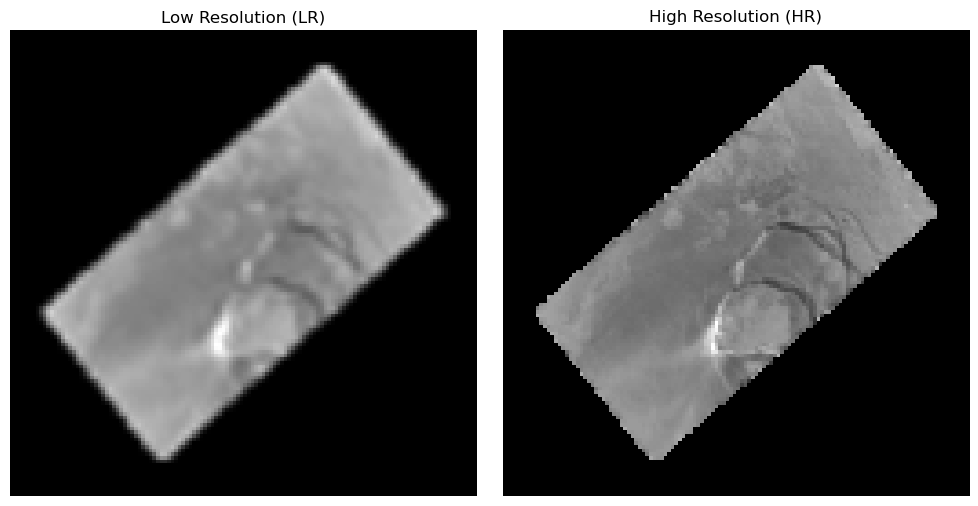

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import rasterio
from rasterio.enums import Resampling

# -------------------------
# Paths
# -------------------------
PROJECT_ROOT = r"D:\SAR_SR_Project"
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")

# -------------------------
# Load preview TIFF paths
# -------------------------
raw_images = []
for ext in ["*.tif", "*.tiff"]:
    raw_images.extend(glob.glob(os.path.join(RAW_DIR, ext)))

preview_tif_paths = [
    p for p in raw_images
    if "preview" in os.path.basename(p).lower()
]

print("Total preview TIFF images found:", len(preview_tif_paths))

# -------------------------
# Parameters
# -------------------------
IMG_SIZE = 128
SCALE = 2
IMAGE_INDEX = 0   # change this if you want another image

# -------------------------
# Preprocess image
# -------------------------
def preprocess_image(image_path, img_size=128):
    with rasterio.open(image_path) as src:
        img = src.read(
            1,
            out_shape=(img_size, img_size),
            resampling=Resampling.bilinear
        ).astype(np.float32)

    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()

    return img

# -------------------------
# Create LR-HR pair
# -------------------------
def create_lr_hr_pair(hr_image, scale=2):
    hr_uint8 = (hr_image * 255).astype(np.uint8)

    pil_img = Image.fromarray(hr_uint8)
    lr = pil_img.resize((IMG_SIZE // scale, IMG_SIZE // scale), Image.BICUBIC)
    lr = lr.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)

    lr = np.array(lr).astype(np.float32) / 255.0
    hr = hr_image.astype(np.float32)

    return lr, hr

# -------------------------
# Generate figure
# -------------------------
hr_img = preprocess_image(preview_tif_paths[IMAGE_INDEX], IMG_SIZE)
lr_img, hr_img = create_lr_hr_pair(hr_img, SCALE)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lr_img, cmap="gray")
plt.title("Low Resolution (LR)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hr_img, cmap="gray")
plt.title("High Resolution (HR)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [2]:
pip install pystac-client planetary-computer requests tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [4]:
import os
import glob
import gc
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import rasterio
from rasterio.enums import Resampling

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [5]:
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


In [6]:
PROJECT_ROOT = r"D:\SAR_SR_Project"
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("RAW_DIR:", RAW_DIR)

RAW_DIR: D:\SAR_SR_Project\data\raw


In [7]:
raw_images = []
for ext in ["*.tif", "*.tiff"]:
    raw_images.extend(glob.glob(os.path.join(RAW_DIR, ext)))

preview_tif_paths = [
    p for p in raw_images
    if "preview" in os.path.basename(p).lower()
]

print("Total preview TIFFs:", len(preview_tif_paths))
for p in preview_tif_paths[:5]:
    print(p)

Total preview TIFFs: 131
D:\SAR_SR_Project\data\raw\20_CAPELLA_C13_SP_GEO_HH_20251108133205_20251108133218_preview.tif
D:\SAR_SR_Project\data\raw\21_CAPELLA_C13_SP_GEO_HH_20251109032756_20251109032808_preview.tif
D:\SAR_SR_Project\data\raw\22_CAPELLA_C13_SP_GEO_HH_20251111090905_20251111090914_preview.tif
D:\SAR_SR_Project\data\raw\23_CAPELLA_C13_SP_GEO_HH_20251111122850_20251111122903_preview.tif
D:\SAR_SR_Project\data\raw\24_CAPELLA_C13_SP_GEO_HH_20251112022441_20251112022453_preview.tif


In [8]:
image_paths = preview_tif_paths.copy()
print("Using total images:", len(image_paths))

Using total images: 131


In [9]:
train_paths, test_paths = train_test_split(image_paths, test_size=0.2, random_state=42)
train_paths, val_paths = train_test_split(train_paths, test_size=0.1, random_state=42)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Train: 93
Val: 11
Test: 27


In [10]:
IMG_SIZE = 128

def preprocess_image(image_path):
    with rasterio.open(image_path) as src:
        img = src.read(
            1,
            out_shape=(IMG_SIZE, IMG_SIZE),
            resampling=Resampling.bilinear
        ).astype(np.float32)

    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()

    return img

In [11]:
def create_lr_hr_pair(hr_image, scale=2):
    hr_uint8 = (hr_image * 255).astype(np.uint8)

    pil_img = Image.fromarray(hr_uint8)
    lr = pil_img.resize((IMG_SIZE // scale, IMG_SIZE // scale), Image.BICUBIC)
    lr = lr.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)

    lr = np.array(lr).astype(np.float32) / 255.0
    hr = hr_image.astype(np.float32)

    return lr, hr

In [12]:
class SARSuperResolutionDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        hr = preprocess_image(self.image_paths[idx])
        lr, hr = create_lr_hr_pair(hr)

        lr = np.expand_dims(lr, axis=0)
        hr = np.expand_dims(hr, axis=0)

        return torch.tensor(lr, dtype=torch.float32), torch.tensor(hr, dtype=torch.float32)

In [13]:
train_dataset = SARSuperResolutionDataset(train_paths)
val_dataset = SARSuperResolutionDataset(val_paths)
test_dataset = SARSuperResolutionDataset(test_paths)

batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))
print("Batch size:", batch_size)

Train dataset: 93
Val dataset: 11
Test dataset: 27
Batch size: 8


In [14]:
for lr_batch, hr_batch in train_loader:
    print("LR batch:", lr_batch.shape)
    print("HR batch:", hr_batch.shape)
    break

LR batch: torch.Size([8, 1, 128, 128])
HR batch: torch.Size([8, 1, 128, 128])


In [15]:
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()

        self.conv3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.conv3(x)
        return x

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for lr_batch, hr_batch in dataloader:
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        optimizer.zero_grad()
        output = model(lr_batch)
        loss = criterion(output, hr_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)

In [17]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for lr_batch, hr_batch in dataloader:
            lr_batch = lr_batch.to(device)
            hr_batch = hr_batch.to(device)

            output = model(lr_batch)
            loss = criterion(output, hr_batch)

            running_loss += loss.item()

    return running_loss / len(dataloader)

In [18]:
def evaluate_model(model, dataset, device):
    model.eval()

    psnr_list = []
    ssim_list = []

    with torch.no_grad():
        for i in range(len(dataset)):
            lr_sample, hr_sample = dataset[i]

            lr_input = lr_sample.unsqueeze(0).to(device)
            sr_output = model(lr_input).cpu().squeeze().numpy()

            hr_img = hr_sample.squeeze().numpy()
            sr_img = np.clip(sr_output, 0, 1)

            psnr_val = psnr(hr_img, sr_img, data_range=1.0)
            ssim_val = ssim(hr_img, sr_img, data_range=1.0)

            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)

    return np.mean(psnr_list), np.mean(ssim_list)

In [19]:
def show_model_output(model, dataset, device, index=0, title="Model Output"):
    model.eval()

    with torch.no_grad():
        lr_sample, hr_sample = dataset[index]

        lr_input = lr_sample.unsqueeze(0).to(device)
        sr_output = model(lr_input).cpu().squeeze().numpy()

        lr_img = lr_sample.squeeze().numpy()
        hr_img = hr_sample.squeeze().numpy()
        sr_img = np.clip(sr_output, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(lr_img, cmap="gray")
    plt.title("Low Resolution Input")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(sr_img, cmap="gray")
    plt.title(title)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(hr_img, cmap="gray")
    plt.title("High Resolution Target")
    plt.axis("off")

    plt.show()

In [20]:
srcnn_model = SRCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(srcnn_model.parameters(), lr=0.001)

num_epochs = 100

srcnn_train_losses = []
srcnn_val_losses = []

best_srcnn_state = None
best_srcnn_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(srcnn_model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(srcnn_model, val_loader, criterion, device)

    srcnn_train_losses.append(train_loss)
    srcnn_val_losses.append(val_loss)

    if val_loss < best_srcnn_val_loss:
        best_srcnn_val_loss = val_loss
        best_srcnn_state = copy.deepcopy(srcnn_model.state_dict())

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1/100 | Train Loss: 0.021580 | Val Loss: 0.009772
Epoch 2/100 | Train Loss: 0.005074 | Val Loss: 0.004215
Epoch 3/100 | Train Loss: 0.002919 | Val Loss: 0.002309
Epoch 4/100 | Train Loss: 0.002034 | Val Loss: 0.001693
Epoch 5/100 | Train Loss: 0.001702 | Val Loss: 0.001529
Epoch 6/100 | Train Loss: 0.001523 | Val Loss: 0.001383
Epoch 7/100 | Train Loss: 0.001406 | Val Loss: 0.001295
Epoch 8/100 | Train Loss: 0.001313 | Val Loss: 0.001230
Epoch 9/100 | Train Loss: 0.001251 | Val Loss: 0.001178
Epoch 10/100 | Train Loss: 0.001193 | Val Loss: 0.001134
Epoch 11/100 | Train Loss: 0.001157 | Val Loss: 0.001099
Epoch 12/100 | Train Loss: 0.001109 | Val Loss: 0.001057
Epoch 13/100 | Train Loss: 0.001068 | Val Loss: 0.001024
Epoch 14/100 | Train Loss: 0.001040 | Val Loss: 0.000992
Epoch 15/100 | Train Loss: 0.000996 | Val Loss: 0.000965
Epoch 16/100 | Train Loss: 0.000965 | Val Loss: 0.000937
Epoch 17/100 | Train Loss: 0.000939 | Val Loss: 0.000912
Epoch 18/100 | Train Loss: 0.000913 | Va

In [21]:
srcnn_model.load_state_dict(best_srcnn_state)
print("Best SRCNN validation loss:", best_srcnn_val_loss)

Best SRCNN validation loss: 0.0005028017039876431


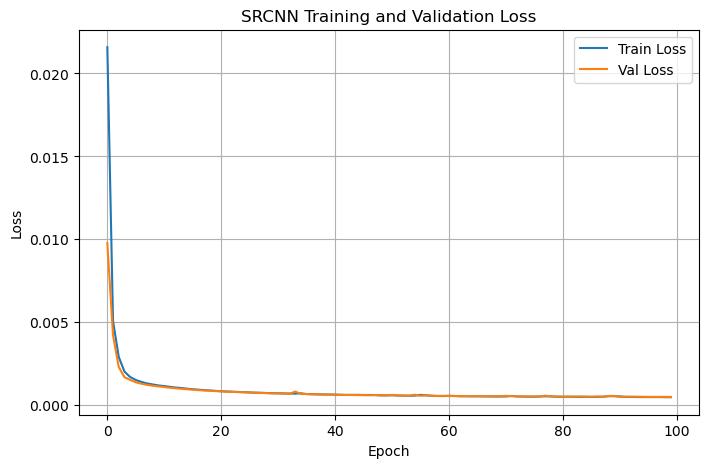

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(srcnn_train_losses, label="Train Loss")
plt.plot(srcnn_val_losses, label="Val Loss")
plt.title("SRCNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
srcnn_psnr, srcnn_ssim = evaluate_model(srcnn_model, test_dataset, device)

print("SRCNN Test PSNR:", srcnn_psnr)
print("SRCNN Test SSIM:", srcnn_ssim)

SRCNN Test PSNR: 33.13785397241958
SRCNN Test SSIM: 0.9551590288705745


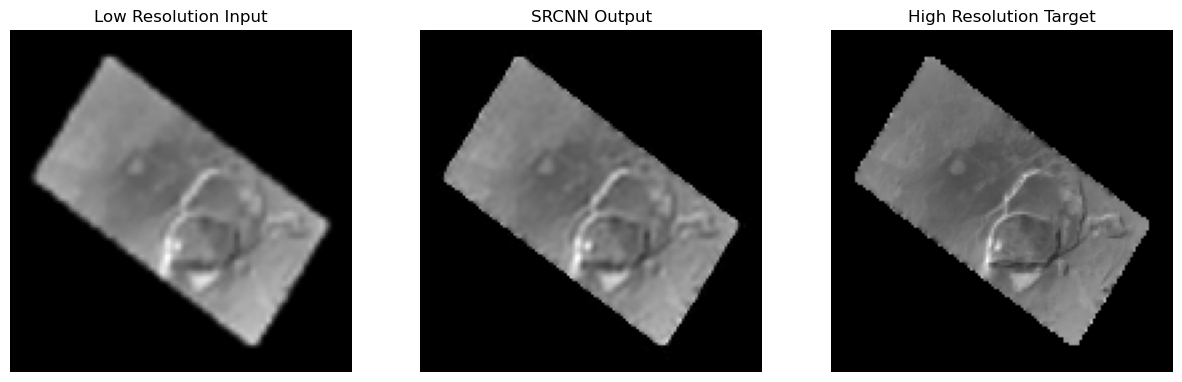

In [24]:
show_model_output(srcnn_model, test_dataset, device, index=0, title="SRCNN Output")

In [25]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super(ResidualBlock, self).__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)

In [26]:
class ResidualSRNet(nn.Module):
    def __init__(self):
        super(ResidualSRNet, self).__init__()

        self.conv_in = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.res1 = ResidualBlock(64)
        self.res2 = ResidualBlock(64)
        self.res3 = ResidualBlock(64)

        self.conv_out = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.relu(self.conv_in(x))
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        x = self.conv_out(x)
        return x

In [27]:
res_model = ResidualSRNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(res_model.parameters(), lr=0.001)

num_epochs = 100

res_train_losses = []
res_val_losses = []

best_res_state = None
best_res_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(res_model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(res_model, val_loader, criterion, device)

    res_train_losses.append(train_loss)
    res_val_losses.append(val_loss)

    if val_loss < best_res_val_loss:
        best_res_val_loss = val_loss
        best_res_state = copy.deepcopy(res_model.state_dict())

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1/100 | Train Loss: 0.055174 | Val Loss: 0.010074
Epoch 2/100 | Train Loss: 0.004783 | Val Loss: 0.002570
Epoch 3/100 | Train Loss: 0.002372 | Val Loss: 0.001790
Epoch 4/100 | Train Loss: 0.001734 | Val Loss: 0.001438
Epoch 5/100 | Train Loss: 0.001398 | Val Loss: 0.001214
Epoch 6/100 | Train Loss: 0.001206 | Val Loss: 0.001105
Epoch 7/100 | Train Loss: 0.001096 | Val Loss: 0.001008
Epoch 8/100 | Train Loss: 0.001018 | Val Loss: 0.000954
Epoch 9/100 | Train Loss: 0.000967 | Val Loss: 0.000909
Epoch 10/100 | Train Loss: 0.000917 | Val Loss: 0.000869
Epoch 11/100 | Train Loss: 0.000876 | Val Loss: 0.000829
Epoch 12/100 | Train Loss: 0.000835 | Val Loss: 0.000787
Epoch 13/100 | Train Loss: 0.000790 | Val Loss: 0.000743
Epoch 14/100 | Train Loss: 0.000740 | Val Loss: 0.000699
Epoch 15/100 | Train Loss: 0.000693 | Val Loss: 0.000662
Epoch 16/100 | Train Loss: 0.000655 | Val Loss: 0.000647
Epoch 17/100 | Train Loss: 0.000625 | Val Loss: 0.000602
Epoch 18/100 | Train Loss: 0.000602 | Va

In [28]:
res_model.load_state_dict(best_res_state)
print("Best Residual model validation loss:", best_res_val_loss)

Best Residual model validation loss: 0.000418677504057996


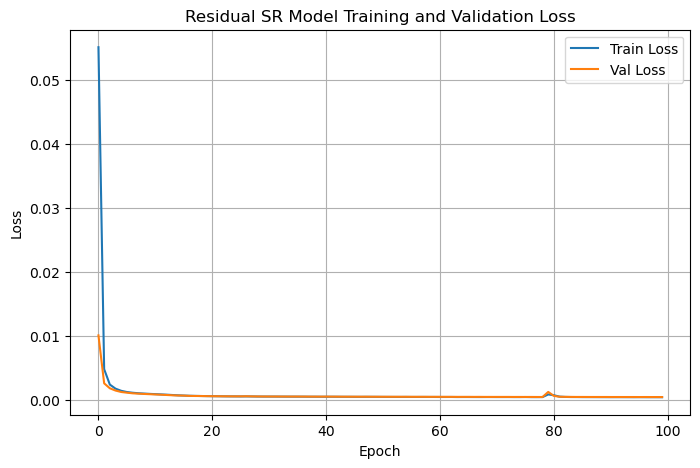

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(res_train_losses, label="Train Loss")
plt.plot(res_val_losses, label="Val Loss")
plt.title("Residual SR Model Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
res_psnr, res_ssim = evaluate_model(res_model, test_dataset, device)

print("Residual SR Test PSNR:", res_psnr)
print("Residual SR Test SSIM:", res_ssim)

Residual SR Test PSNR: 34.04275285665309
Residual SR Test SSIM: 0.961071569495207


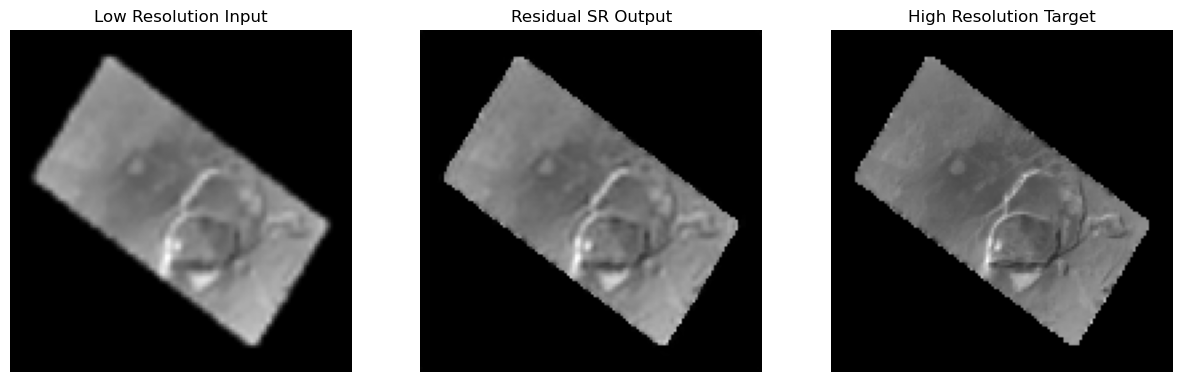

In [31]:
show_model_output(res_model, test_dataset, device, index=0, title="Residual SR Output")

In [32]:
print("Final Comparison")
print("-" * 40)
print(f"SRCNN       | PSNR: {srcnn_psnr:.4f} | SSIM: {srcnn_ssim:.4f}")
print(f"Residual SR | PSNR: {res_psnr:.4f} | SSIM: {res_ssim:.4f}")

Final Comparison
----------------------------------------
SRCNN       | PSNR: 33.1379 | SSIM: 0.9552
Residual SR | PSNR: 34.0428 | SSIM: 0.9611
